# Guía para Análisis Exploratorio de Datos (EDA)

## Paso 1: Inspección General (Data Understanding)
El objetivo aquí es conocer la forma y la naturaleza básica de tu dataset.

*   **Estructura**: Revisar la cantidad de filas y columnas (`df.shape`).
*   **Tipos de Datos**: Identificar qué columnas son numéricas, categóricas o temporales (`df.info()`, `df.dtypes`).
*   **Muestra**: Observar las primeras y últimas filas para entender el contexto real de los datos (`df.head()`, `df.tail()`).
*   **Estadística Descriptiva**: Obtener un resumen de la media, desviación estándar, mínimos y máximos de las variables numéricas (`df.describe()`).

## Paso 2: Limpieza y Calidad de Datos (Data Quality & Cleaning)
Antes de buscar patrones, hay que asegurar que los datos sean confiables.

*   **Valores Nulos**: Cuantificar la cantidad de datos faltantes por columna (`df.isnull().sum()`) y decidir si se imputan (rellenan) o se eliminan.
*   **Duplicados**: Identificar y remover filas exactamente iguales que puedan sesgar el análisis (`df.duplicated()`).
*   **Inconsistencias**: Corregir errores tipográficos en variables categóricas o formatos de fecha incorrectos.

## Paso 3: Análisis Univariado (Univariate Analysis)
Analizar cada variable de forma individual para entender su distribución.

*   **Variables Numéricas**: Usar histogramas para ver la distribución de frecuencias y boxplots (diagramas de caja) para identificar valores atípicos (outliers).
*   **Variables Categóricas**: Usar gráficos de barras o conteos de frecuencia (`value_counts()`) para ver la proporción de cada categoría.

## Paso 4: Análisis Bivariado y Multivariado (Multivariate Analysis)
Aquí es donde comienza la magia: encontrar las relaciones entre diferentes variables.

*   **Correlación**: Crear una matriz de correlación (heatmap) para ver qué variables numéricas se mueven juntas (ej. velocidad vs. RPM).
*   **Dispersión (Scatter Plots)**: Graficar pares de variables para identificar tendencias o agrupaciones (clusters).
*   **Segmentación**: Agrupar datos numéricos por categorías (ej. velocidad promedio agrupada por cada piloto) usando `groupby`.

## Paso 5: Generación de Insights (Feature Engineering Preliminar)
Basado en lo que observaste en los pasos anteriores, tomas decisiones sobre las variables.

*   **Creación**: Derivar nuevas columnas útiles (ej. crear una columna "tiempo de vuelta en segundos" a partir de un timestamp).
*   **Transformación**: Aplicar logaritmos o normalización si los datos están muy sesgados.
*   **Selección**: Descartar columnas que tienen el 99% de valores nulos o que no aportan varianza al estudio.

## Paso 6: Resumen y Conclusiones (Reporting)
El cierre del pipeline no es código, es comunicación.

*   **Documentación**: Anotar los hallazgos principales, las limitaciones del dataset y cómo se trataron los valores atípicos o nulos.
*   **Preparación para la siguiente fase**: Exportar el dataset "limpio" y listo para el modelado o la creación de dashboards (`df.to_csv()` o `df.to_parquet()`).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
RACE        = 'china_2026'         # cambiá por la carrera que querés
DRIVERS     = [16, 44]                 # números de piloto
DRIVER_COLORS = {16: '#DC0000', 44: "#000000"}  
DRIVER_NAMES  = {16: 'LEC', 44: 'HAM'}   # ajustá si son otros pilotos

In [4]:
import pandas as pd

# Leer una carrera
df = pd.read_parquet("C:\\Users\\marce\\F1-data-project\\project\\data\\processed\\china_2026.parquet")

# Ver estructura básica
print(df.shape)          # (filas, columnas)
print(df.columns.tolist())  # todas las columnas


(112, 19)
['meeting_key', 'session_key', 'driver_number', 'lap_number', 'date_start', 'duration_sector_1', 'duration_sector_2', 'duration_sector_3', 'i1_speed', 'i2_speed', 'is_pit_out_lap', 'lap_duration', 'segments_sector_1', 'segments_sector_2', 'segments_sector_3', 'st_speed', 'pit_duration', 'PitStop', 'fuel_load_est']


In [5]:
df.head()    # primeras 5 filas


,meeting_key,session_key,driver_number,lap_number,date_start,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,is_pit_out_lap,lap_duration,segments_sector_1,segments_sector_2,segments_sector_3,st_speed,pit_duration,PitStop,fuel_load_est
0,1280,11245,16,1,2026-03-15T07:03:59.830000+00:00,28.987,30.192,42.302,292.0,256,False,101.481,"[None, 2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 204...",320,NaN,0,105.0
1,1280,11245,16,2,2026-03-15T07:05:41.310000+00:00,25.954,29.998,42.606,276.0,267,False,98.558,"[2049, 2049, 2049, 2049, 2049, 2048, 2048]","[2049, 2049, 2051, 2048, 2048, 2049]","[2048, 2048, 2049, 2049, 2048, 2048, 2049, 204...",314,NaN,0,103.125
2,1280,11245,16,3,2026-03-15T07:07:19.888000+00:00,26.669,29.902,42.577,265.0,255,False,99.148,"[2048, 2048, 2048, 2048, 2049, 2048, 2048]","[2048, 2048, 2048, 2049, 2048, 2048]","[2048, 2048, 2048, 2048, 2048, 2048, 2049, 204...",324,NaN,0,101.25
3,1280,11245,16,4,2026-03-15T07:08:59.025000+00:00,25.914,29.661,42.260,272.0,256,False,97.835,"[None, 2048, 2049, 2048, 2049, 2048, 2048]","[2049, 2048, 2048, 2049, 2049, 2048]","[2049, 2048, 2048, 2048, 2048, 2049, 2049, 204...",314,NaN,0,99.375
4,1280,11245,16,5,2026-03-15T07:10:36.879000+00:00,NaN,29.632,42.317,265.0,255,False,97.863,"[2049, 2049, 2049, 2049, 2048, 2048, 2048]","[2048, 2048, 2048, 2049, 2048, 2048]","[2048, 2048, 2048, 2048, 2048, 2049, 2048, 204...",320,NaN,0,97.5


In [6]:
print(df.dtypes)         # tipos de dato

meeting_key            int64
session_key            int64
driver_number          Int64
lap_number             Int64
date_start            object
duration_sector_1    float64
duration_sector_2    float64
duration_sector_3    float64
i1_speed             float64
i2_speed               int64
is_pit_out_lap          bool
lap_duration         float64
segments_sector_1     object
segments_sector_2     object
segments_sector_3     object
st_speed               int64
pit_duration         float64
PitStop                int64
fuel_load_est        Float64
dtype: object


In [7]:
df.isna().sum()

meeting_key            0
session_key            0
driver_number          0
lap_number             0
date_start             0
duration_sector_1      1
duration_sector_2      0
duration_sector_3      0
i1_speed              11
i2_speed               0
is_pit_out_lap         0
lap_duration           0
segments_sector_1      0
segments_sector_2      0
segments_sector_3      0
st_speed               0
pit_duration         110
PitStop                0
fuel_load_est          0
dtype: int64

In [8]:
df.columns

Index(['meeting_key', 'session_key', 'driver_number', 'lap_number',
       'date_start', 'duration_sector_1', 'duration_sector_2',
       'duration_sector_3', 'i1_speed', 'i2_speed', 'is_pit_out_lap',
       'lap_duration', 'segments_sector_1', 'segments_sector_2',
       'segments_sector_3', 'st_speed', 'pit_duration', 'PitStop',
       'fuel_load_est'],
      dtype='object')

In [9]:


# 2. pit_duration → 0 si no hubo pit
df['pit_duration'] = df['pit_duration'].fillna(0)

# 3. Sectores y velocidades → mediana por piloto
cols_impute = [   'i1_speed']
for col in cols_impute:
    df[col] = df.groupby('driver_number')[col].transform(
        lambda x: x.fillna(x.median())
    )

df.isnull().sum()

meeting_key          0
session_key          0
driver_number        0
lap_number           0
date_start           0
duration_sector_1    1
duration_sector_2    0
duration_sector_3    0
i1_speed             0
i2_speed             0
is_pit_out_lap       0
lap_duration         0
segments_sector_1    0
segments_sector_2    0
segments_sector_3    0
st_speed             0
pit_duration         0
PitStop              0
fuel_load_est        0
dtype: int64

In [10]:
print('── Estadísticas descriptivas ──────────')
num_cols = df.select_dtypes(include='number').columns.tolist()
df[num_cols].describe().round(3)

── Estadísticas descriptivas ──────────


,meeting_key,session_key,driver_number,lap_number,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,lap_duration,st_speed,pit_duration,PitStop,fuel_load_est
count,112.0,112.0,112.0,112.0,111.000,112.000,112.000,112.000,112.000,112.000,112.000,112.000,112.000,112.0
mean,1280.0,11245.0,30.0,28.5,26.805,30.088,43.528,265.036,252.723,100.413,302.562,0.429,0.018,53.438
std,0.0,0.0,14.063,16.236,4.960,3.207,5.231,22.086,18.297,12.870,29.421,3.204,0.133,30.442
min,1280.0,11245.0,16.0,1.0,25.047,28.856,41.598,116.000,157.000,96.011,154.000,0.000,0.000,1.875
25%,1280.0,11245.0,16.0,14.75,25.413,29.111,41.936,265.750,253.000,96.511,302.000,0.000,0.000,27.656
50%,1280.0,11245.0,30.0,28.5,25.680,29.246,42.082,268.000,256.000,96.923,306.000,0.000,0.000,53.438
75%,1280.0,11245.0,44.0,42.25,25.931,29.633,42.285,272.000,260.000,97.937,315.250,0.000,0.000,79.219
max,1280.0,11245.0,44.0,56.0,57.124,45.067,67.058,292.000,268.000,162.319,336.000,25.633,1.000,105.0


C:\Users\marce\AppData\Local\Temp\ipykernel_10220\1397243352.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True, widths=0.4)


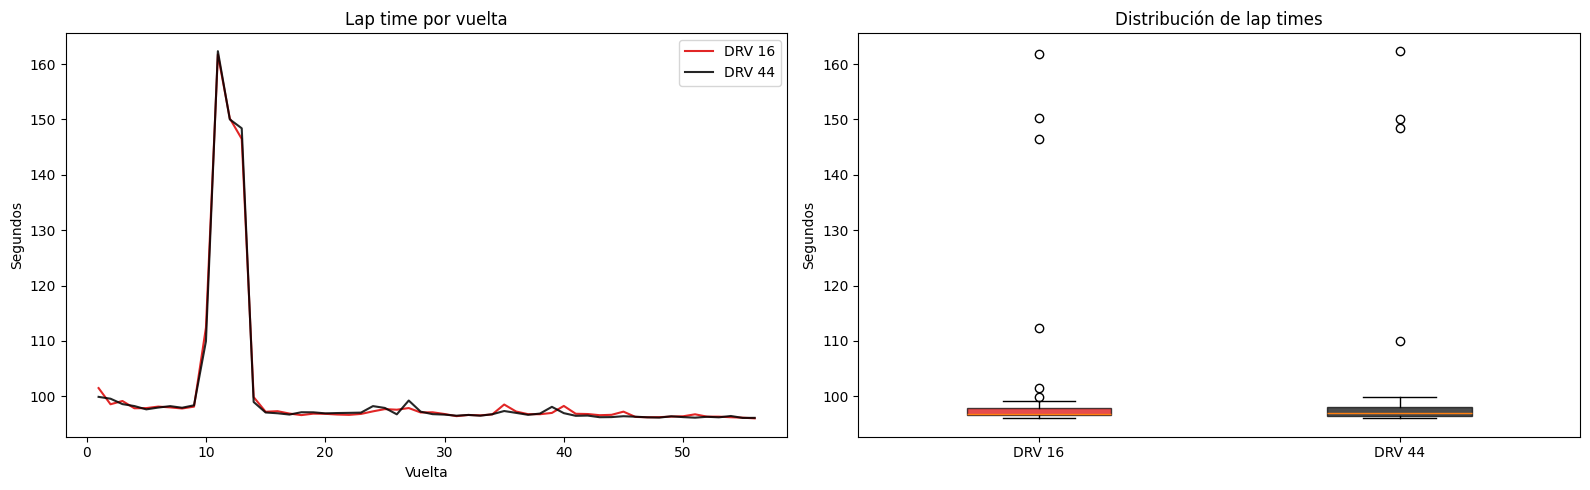

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 2a. Lap time por vuelta (línea)
ax = axes[0]
for drv in DRIVERS:
    sub = df[df['driver_number'] == drv].sort_values('lap_number')
    color = DRIVER_COLORS.get(drv, None)
    label = sub['name_acronym'].iloc[0] if 'name_acronym' in sub.columns else f'DRV {drv}'
    ax.plot(sub['lap_number'], sub['lap_duration'], label=label,
            color=color, linewidth=1.5, alpha=0.85)
    # Marcar pit stops
    if 'pit_stop' in sub.columns:
        pits = sub[sub['pit_stop'] > 0]
        ax.scatter(pits['lap_number'], pits['lap_duration'],
                   color=color, marker='v', s=80, zorder=5)

ax.set_title('Lap time por vuelta')
ax.set_xlabel('Vuelta')
ax.set_ylabel('Segundos')
ax.legend()

# 2b. Distribución de lap times (boxplot)
ax = axes[1]
plot_data = []
labels = []
colors = []
for drv in DRIVERS:
    sub = df[df['driver_number'] == drv]['lap_duration'].dropna()
    plot_data.append(sub.values)
    name = df[df['driver_number'] == drv]['name_acronym'].iloc[0] \
           if 'name_acronym' in df.columns else f'DRV {drv}'
    labels.append(name)
    colors.append(DRIVER_COLORS.get(drv, 'gray'))

bp = ax.boxplot(plot_data, labels=labels, patch_artist=True, widths=0.4)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Distribución de lap times')
ax.set_ylabel('Segundos')
plt.tight_layout()
plt.savefig('eda_ritmo.png', dpi=120, bbox_inches='tight')
plt.show()

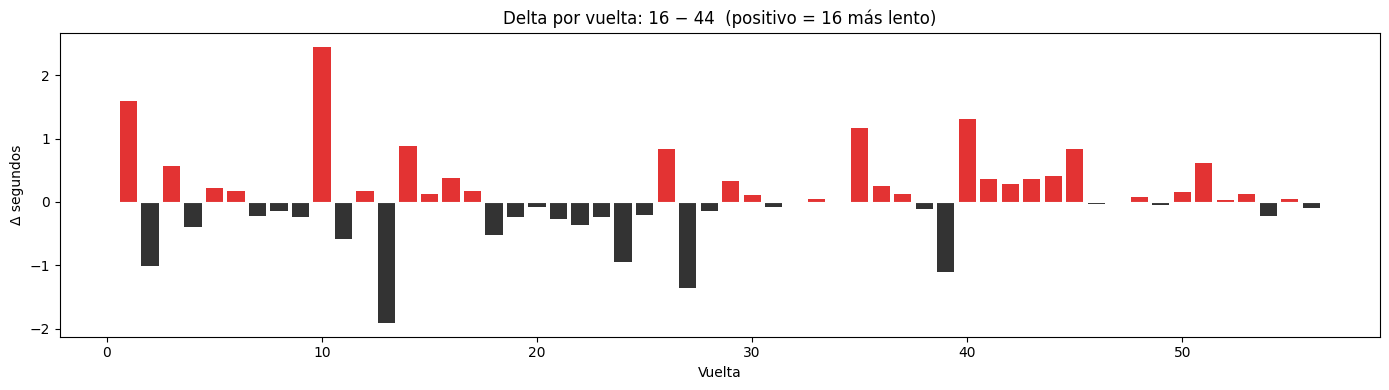

Ventaja acumulada 16: 3.60s


In [12]:
# Delta entre pilotos vuelta a vuelta
if len(DRIVERS) == 2:
    d1 = df[df['driver_number'] == DRIVERS[0]][['lap_number','lap_duration']].set_index('lap_number')
    d2 = df[df['driver_number'] == DRIVERS[1]][['lap_number','lap_duration']].set_index('lap_number')
    delta = (d1['lap_duration'] - d2['lap_duration']).dropna()

    fig, ax = plt.subplots(figsize=(14, 4))
    colors_delta = [DRIVER_COLORS[DRIVERS[0]] if v > 0 else DRIVER_COLORS[DRIVERS[1]] for v in delta]
    ax.bar(delta.index, delta.values, color=colors_delta, alpha=0.8)
    ax.axhline(0, color='white', linewidth=0.8)
    n0 = df[df['driver_number']==DRIVERS[0]]['name_acronym'].iloc[0] if 'name_acronym' in df.columns else str(DRIVERS[0])
    n1 = df[df['driver_number']==DRIVERS[1]]['name_acronym'].iloc[0] if 'name_acronym' in df.columns else str(DRIVERS[1])
    ax.set_title(f'Delta por vuelta: {n0} − {n1}  (positivo = {n0} más lento)')
    ax.set_xlabel('Vuelta')
    ax.set_ylabel('Δ segundos')
    plt.tight_layout()
    plt.savefig('eda_delta.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Ventaja acumulada {n0}: {delta.sum():.2f}s')

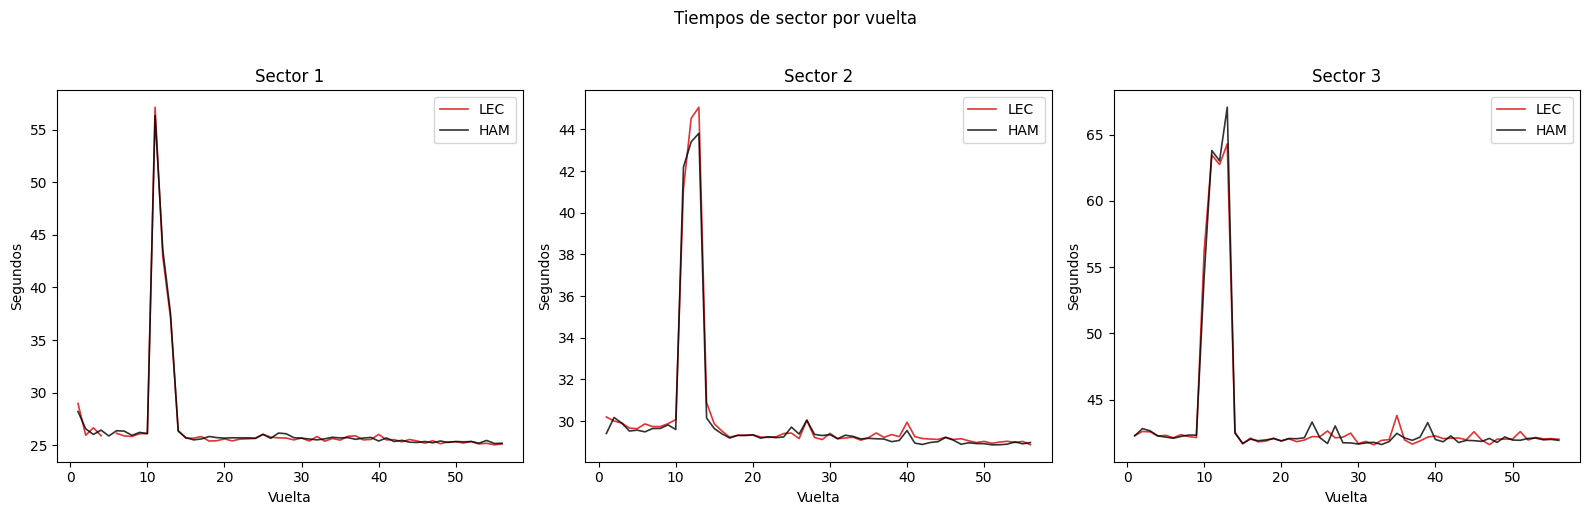

── Mejor tiempo por sector ────────────
  LEC duration_sector_1: 25.047s
  LEC duration_sector_2: 28.862s
  LEC duration_sector_3: 41.598s
  HAM duration_sector_1: 25.176s
  HAM duration_sector_2: 28.856s
  HAM duration_sector_3: 41.620s


In [13]:
sector_cols = [c for c in ['duration_sector_1', 'duration_sector_2', 'duration_sector_3']
               if c in df.columns]

if sector_cols:
    fig, axes = plt.subplots(1, len(sector_cols), figsize=(16, 5), sharey=False)
    if len(sector_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, sector_cols):
        for drv in DRIVERS:
            sub = df[df['driver_number'] == drv]
            ax.plot(sub['lap_number'], sub[col],
                    label=DRIVER_NAMES.get(drv, str(drv)),
                    color=DRIVER_COLORS.get(drv), linewidth=1.2, alpha=0.8)
        ax.set_title(col.replace('duration_', '').replace('_', ' ').title())
        ax.set_xlabel('Vuelta')
        ax.set_ylabel('Segundos')
        ax.legend()

    plt.suptitle('Tiempos de sector por vuelta', y=1.02)
    plt.tight_layout()
    plt.savefig('eda_03_sectores.png', dpi=120, bbox_inches='tight')
    plt.show()

    # Mejor sector por piloto
    print('── Mejor tiempo por sector ────────────')
    for drv in DRIVERS:
        sub = df[df['driver_number'] == drv]
        name = DRIVER_NAMES.get(drv, str(drv))
        for col in sector_cols:
            print(f'  {name} {col}: {sub[col].min():.3f}s')

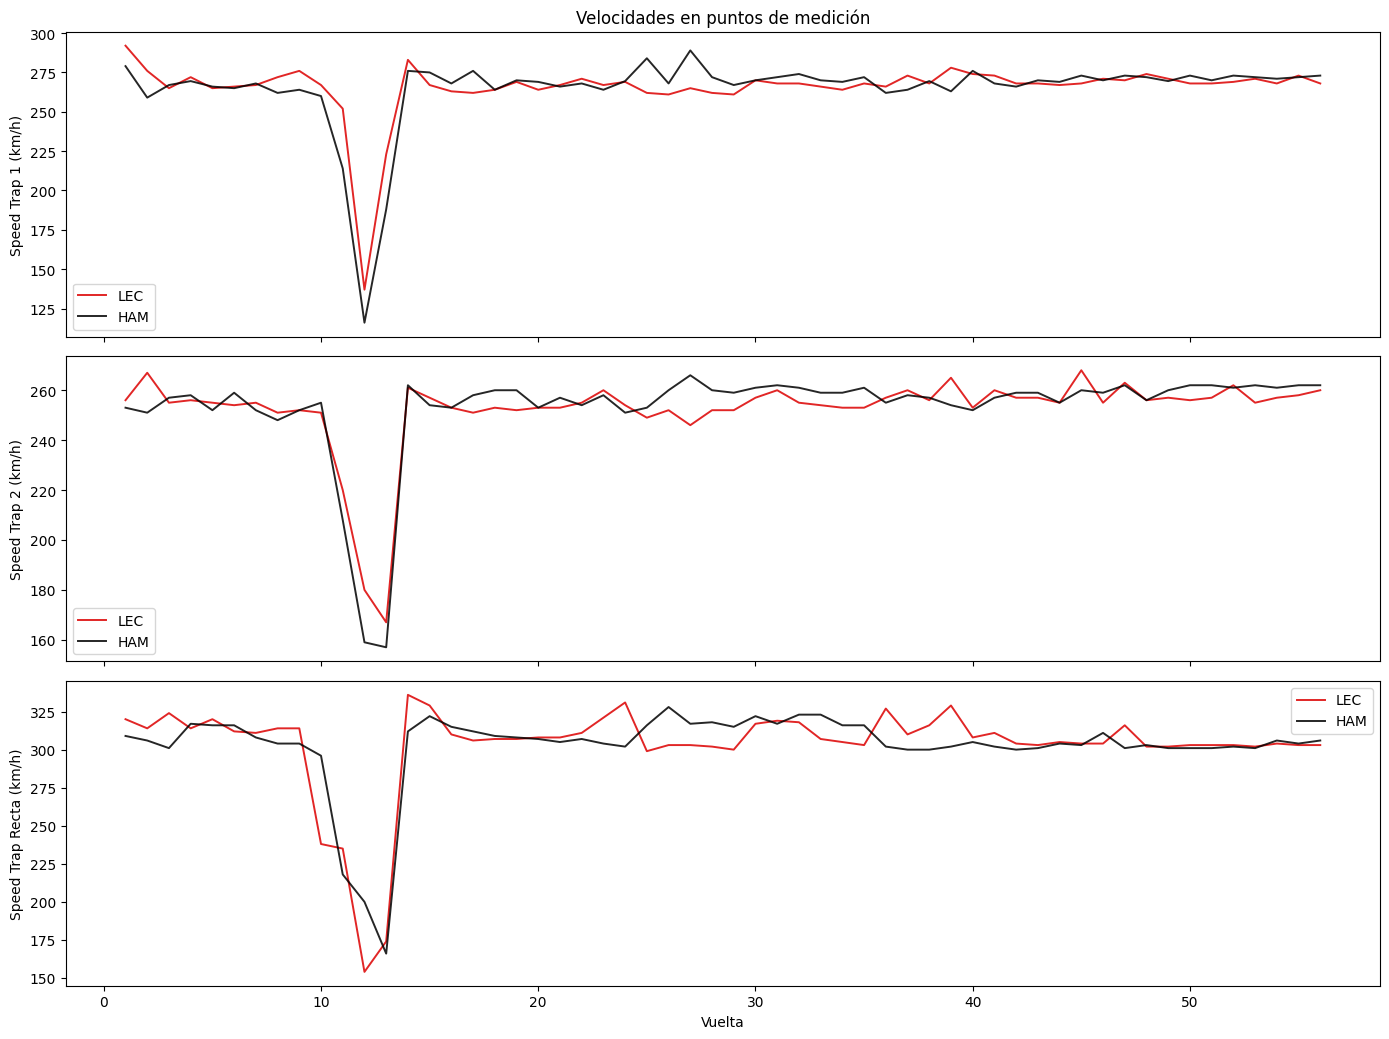

── Velocidad máxima por piloto ────────
  LEC i1_speed: 292.0 km/h
  LEC i2_speed: 268.0 km/h
  LEC st_speed: 336.0 km/h
  HAM i1_speed: 289.0 km/h
  HAM i2_speed: 266.0 km/h
  HAM st_speed: 328.0 km/h


In [14]:
speed_cols = [c for c in ['i1_speed', 'i2_speed', 'st_speed'] if c in df.columns]

if speed_cols:
    fig, axes = plt.subplots(len(speed_cols), 1,
                             figsize=(14, 3.5 * len(speed_cols)), sharex=True)
    if len(speed_cols) == 1:
        axes = [axes]

    labels_map = {'i1_speed': 'Speed Trap 1 (km/h)',
                  'i2_speed': 'Speed Trap 2 (km/h)',
                  'st_speed': 'Speed Trap Recta (km/h)'}

    for ax, col in zip(axes, speed_cols):
        for drv in DRIVERS:
            sub = df[df['driver_number'] == drv]
            ax.plot(sub['lap_number'], sub[col],
                    label=DRIVER_NAMES.get(drv, str(drv)),
                    color=DRIVER_COLORS.get(drv), linewidth=1.4, alpha=0.85)
        ax.set_ylabel(labels_map.get(col, col))
        ax.legend()

    axes[-1].set_xlabel('Vuelta')
    axes[0].set_title('Velocidades en puntos de medición')
    plt.tight_layout()
    plt.savefig('eda_04_velocidades.png', dpi=120, bbox_inches='tight')
    plt.show()

    # Comparativa de velocidad máxima
    print('── Velocidad máxima por piloto ────────')
    for drv in DRIVERS:
        sub = df[df['driver_number'] == drv]
        name = DRIVER_NAMES.get(drv, str(drv))
        for col in speed_cols:
            print(f'  {name} {col}: {sub[col].max():.1f} km/h')

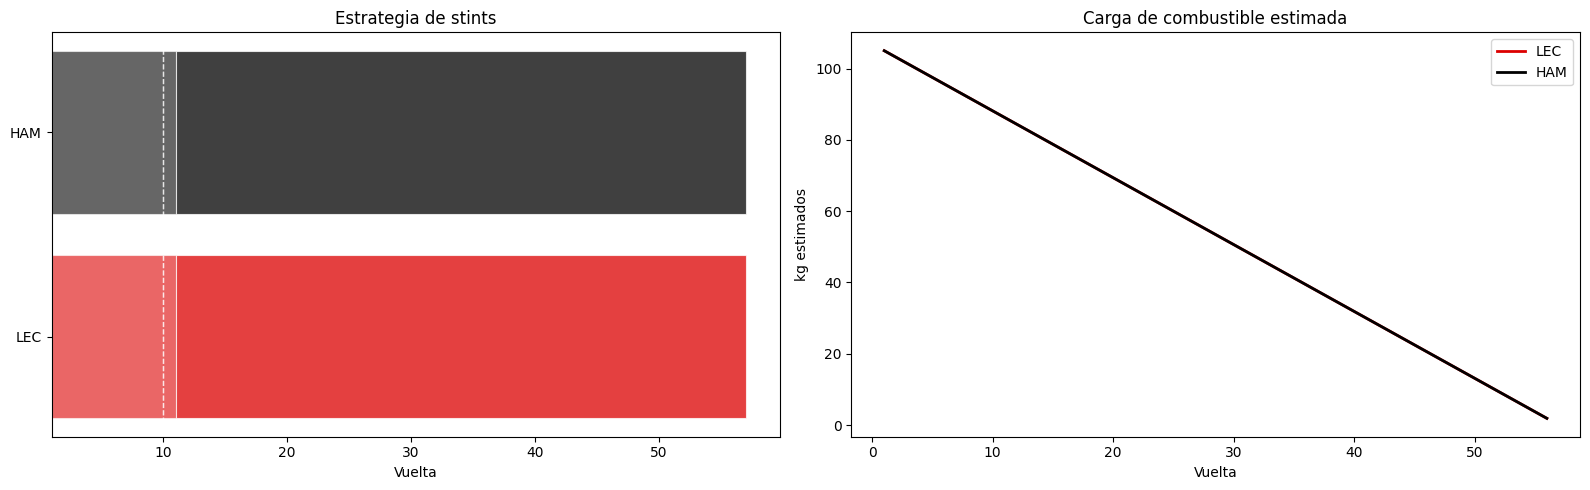

── Resumen pit stops ──────────────────
driver  lap_number  pit_duration
   LEC          10        25.633
   HAM          10        22.433


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 6a. Estrategia de pit stops (barras horizontales por stint)
ax = axes[0]
for i, drv in enumerate(DRIVERS):
    sub  = df[df['driver_number'] == drv].sort_values('lap_number')
    name = DRIVER_NAMES.get(drv, str(drv))
    color = DRIVER_COLORS.get(drv)

    if 'PitStop' in sub.columns:
        pit_laps = sub[sub['PitStop'] > 0]['lap_number'].tolist()
        stints = [1] + [p + 1 for p in pit_laps]
        ends   = pit_laps + [sub['lap_number'].max()]
        for j, (start, end) in enumerate(zip(stints, ends)):
            ax.barh(name, end - start + 1, left=start,
                    color=color, alpha=0.6 + 0.15 * j,
                    edgecolor='white', linewidth=0.8)
        for pit in pit_laps:
            ax.axvline(pit, color='white', linewidth=1, alpha=0.6, linestyle='--')

ax.set_title('Estrategia de stints')
ax.set_xlabel('Vuelta')

# 6b. Fuel load estimado
ax = axes[1]
if 'fuel_load_est' in df.columns:
    for drv in DRIVERS:
        sub = df[df['driver_number'] == drv]
        ax.plot(sub['lap_number'], sub['fuel_load_est'],
                label=DRIVER_NAMES.get(drv, str(drv)),
                color=DRIVER_COLORS.get(drv), linewidth=2)
    ax.set_title('Carga de combustible estimada')
    ax.set_xlabel('Vuelta')
    ax.set_ylabel('kg estimados')
    ax.legend()

plt.tight_layout()
plt.savefig('eda_05_pitstops.png', dpi=120, bbox_inches='tight')
plt.show()

# Resumen de pit stops
if 'PitStop' in df.columns and 'pit_duration' in df.columns:
    print('── Resumen pit stops ──────────────────')
    pit_resumen = df[df['PitStop'] > 0][['driver_number', 'lap_number', 'pit_duration']]
    pit_resumen['driver'] = pit_resumen['driver_number'].map(DRIVER_NAMES)
    print(pit_resumen[['driver', 'lap_number', 'pit_duration']].to_string(index=False))

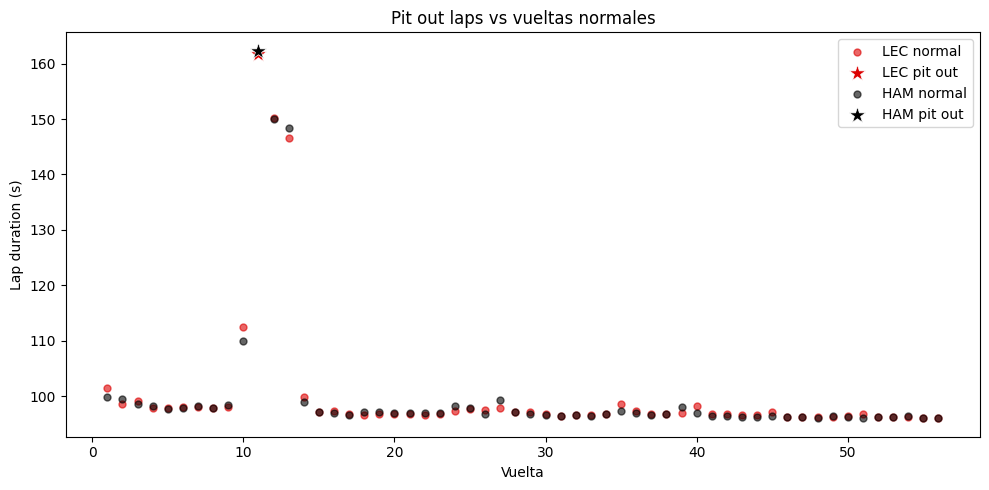

In [16]:
if 'is_pit_out_lap' in df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    for drv in DRIVERS:
        sub  = df[df['driver_number'] == drv]
        name = DRIVER_NAMES.get(drv, str(drv))
        color = DRIVER_COLORS.get(drv)
        normal  = sub[sub['is_pit_out_lap'] != True]
        pit_out = sub[sub['is_pit_out_lap'] == True]

        ax.scatter(normal['lap_number'], normal['lap_duration'],
                   color=color, alpha=0.6, s=25, label=f'{name} normal')
        ax.scatter(pit_out['lap_number'], pit_out['lap_duration'],
                   color=color, marker='*', s=150, zorder=5,
                   edgecolors='white', linewidths=0.5, label=f'{name} pit out')

    ax.set_title('Pit out laps vs vueltas normales')
    ax.set_xlabel('Vuelta')
    ax.set_ylabel('Lap duration (s)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('eda_06_pitout.png', dpi=120, bbox_inches='tight')
    plt.show()

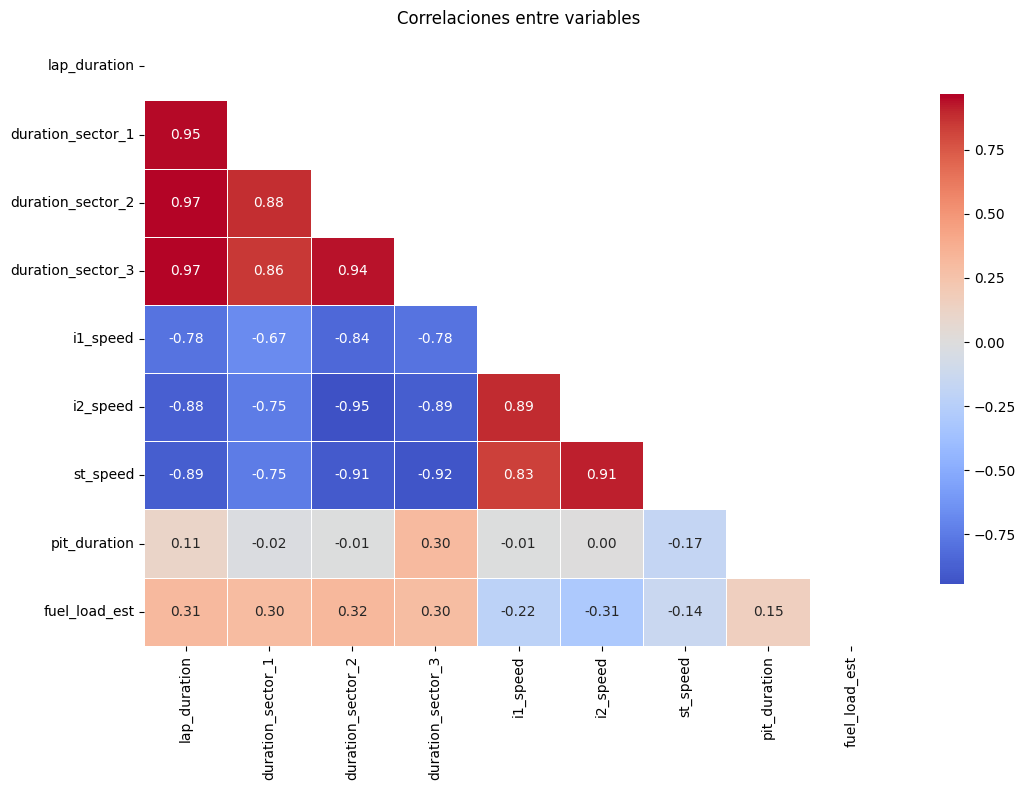

In [17]:
corr_cols = [c for c in [
    'lap_duration', 'duration_sector_1', 'duration_sector_2', 'duration_sector_3',
    'i1_speed', 'i2_speed', 'st_speed', 'pit_duration', 'fuel_load_est'
] if c in df.columns]

corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlaciones entre variables')
plt.tight_layout()
plt.savefig('eda_07_correlaciones.png', dpi=120, bbox_inches='tight')
plt.show()


In [18]:
resumen_cols = [c for c in [
    'lap_duration', 'duration_sector_1', 'duration_sector_2', 'duration_sector_3',
    'i1_speed', 'i2_speed', 'st_speed', 'fuel_load_est'
] if c in df.columns]

resumen = df.groupby('driver_number')[resumen_cols].agg(['mean', 'median', 'std', 'min', 'max'])
resumen.columns = ['_'.join(c) for c in resumen.columns]
resumen.index   = resumen.index.map(DRIVER_NAMES)
resumen.round(3)

,lap_duration_mean,lap_duration_median,lap_duration_std,lap_duration_min,lap_duration_max,duration_sector_1_mean,duration_sector_1_median,duration_sector_1_std,duration_sector_1_min,duration_sector_1_max,...,st_speed_mean,st_speed_median,st_speed_std,st_speed_min,st_speed_max,fuel_load_est_mean,fuel_load_est_median,fuel_load_est_std,fuel_load_est_min,fuel_load_est_max
driver_number,,,,,,,,,,,,,,,,,,,,,
LEC,100.445,96.869,12.859,96.011,161.733,26.785,25.616,5.030,25.047,57.124,...,302.786,307.0,31.587,154,336,53.438,53.438,30.58,1.875,105.0
HAM,100.381,96.941,12.998,96.092,162.319,26.824,25.703,4.936,25.176,56.333,...,302.339,305.5,27.370,166,328,53.438,53.438,30.58,1.875,105.0
